# REFS

The RRFS Ensemble Forecast System (REFS) will be/was implemented by NOAA National Centers for Environmental Prediction (NCEP) on October 14, 2026. _Pre-implementation_ data were made available starting August 11, 2026.

> **Note that the RRFS Ensemble Forecast System (REFS) is a separate model from the ensemble output of the Rapid Refresh Forecast System (RRFS).**

REFS is a replacement for the High-Resolution Ensemble Forecast system (HREF). It usilizes the current and 6 h old cycles of RRFS, and for some domains uses the current High-Resolution Rapid Refresh (HRRR) and the 6 h old HRRR.

See this Service Change Notice from National Weather Service for more details: https://www.weather.gov/media/notification/pdf_2026/scn26-048_Updated_RRFS_and_REFS_Implementation_aad.pdf.

There were some prototype products and forecasts available on the cloud on AWS, but they appear to have been reorganized and are no longer directly accessible with Herbie. 

In [1]:
from herbie import Herbie, FastHerbie
from herbie.toolbox import EasyMap, pc
from herbie import paint
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
H = Herbie(
    "2026-08-15 12:00",
    model="refs",
    fxx=1,
    product="mean",
    domain="conus",
)

H.SOURCES

✅ Found ┊ model=refs ┊ product=mean ┊ 2026-Aug-15 12:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local


{'aws': 'https://noaa-rrfs-ops-pds.s3.amazonaws.com/refs.20260815/12/ensprod/refs.t12z.mean.f01.conus.grib2',
 'nomads': 'https://nomads.ncep.noaa.gov/pub/data/nccf/com/refs/v1.0/refs.20260815/12/ensprod/refs.t12z.mean.f01.conus.grib2'}

In [9]:
H.help()

╭─ Herbie ────────────────────────────────
│ Help for model='refs'
│ 
│ Rapid Refresh Forecast System (RRFS)
│  aws product description: https://registry.opendata.aws/noaa-rrfs-ops/
│
│ Herbie(date, model='refs', ...)
│ 
│ fxx : int
│ product : {"mean", "sprd", "pmmn", "lpmm", "avrg", "prob", "eas", "ffri"}
│ domain : {"conus", "alaska", "hawaii", "puerto rico", "na"}
│
╰─────────────────────────────────────────


In [10]:
ds = H.xarray("TMP:2 m above ground")
ds

<xarray.Dataset> Size: 38MB
Dimensions:              (y: 1059, x: 1799)
Coordinates:
    latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    time                 datetime64[ns] 8B 2026-08-15T12:00:00
    step                 timedelta64[ns] 8B 01:00:00
    heightAboveGround    float64 8B 2.0
    valid_time           datetime64[ns] 8B 2026-08-15T13:00:00
    gribfile_projection  object 8B None
Dimensions without coordinates: y, x
Data variables:
    t2m                  (y, x) float32 8MB 298.7 298.7 298.7 ... 290.2 290.1
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   refs
    product:                 mean
    description:             Rapid Refresh Forecast System (RRFS)
    remote_grib:             https://noaa-rrfs-ops-pds.s3.amazonaws.com/refs....
    local_grib:              C:\Users\willh\data\refs\20260815\subset_cce49ae...
    search:                  TMP:2 m above ground

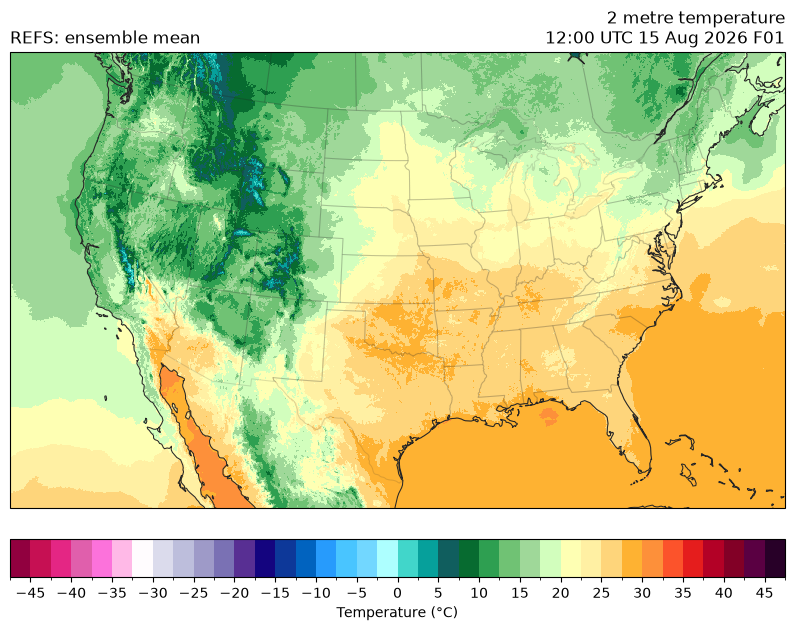

In [11]:
ax = EasyMap("50m", crs=ds.herbie.crs, figsize=[10, 8]).STATES().ax
p = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.t2m - 273.15,
    transform=pc,
    **paint.NWSTemperature.kwargs2,
)
plt.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05, **paint.NWSTemperature.cbar_kwargs2
)

ax.set_title(
    f"{ds.t2m.GRIB_name}\n{ds.time.dt.strftime('%H:%M UTC %d %b %Y').item()} F{int(ds.step.dt.total_seconds() / 60 / 60):02d}",
    loc="right",
)
ax.set_title(
    f"{H.model.upper()}: {H.product_description}", loc="left"
)
plt.show()

✅ Found ┊ model=refs ┊ product=sprd ┊ 2026-Aug-15 12:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local


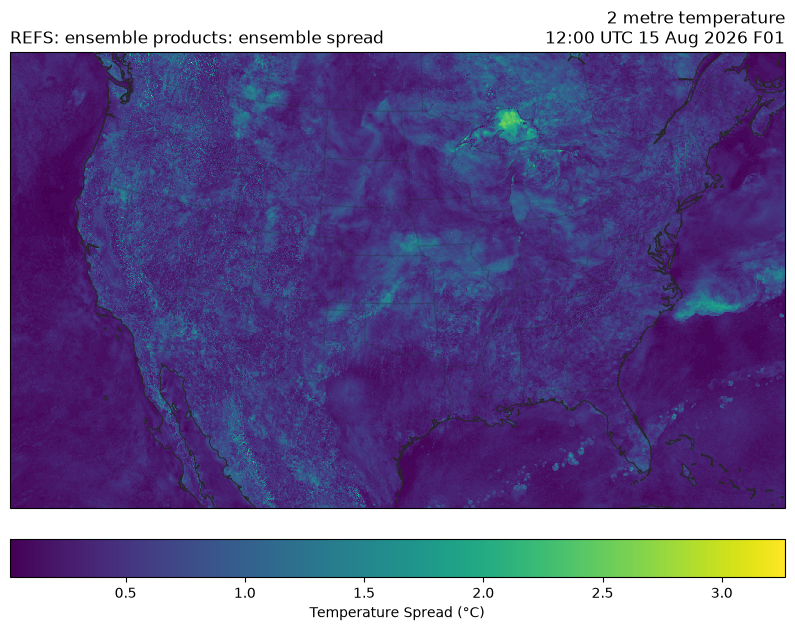

In [18]:
H = Herbie(
    "2026-08-15 12:00",
    model="refs",
    fxx=1,
    product="sprd",
    domain="conus",
)

ds = H.xarray("TMP:2 m above ground")

ax = EasyMap("50m", crs=ds.herbie.crs, figsize=[10, 8]).STATES().ax
p = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.t2m,
    transform=pc,
)
plt.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05,
    label='Temperature Spread ($\\degree$C)'
)

ax.set_title(
    f"{ds.t2m.GRIB_name}\n{ds.time.dt.strftime('%H:%M UTC %d %b %Y').item()} F{int(ds.step.dt.total_seconds() / 60 / 60):02d}",
    loc="right",
)
ax.set_title(
    f"{H.model.upper()}: {H.product_description}", loc="left"
)
plt.show()